#  Calculation of features from available libraries

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
dataset = 'Fe-Mo'  # 'Cr-Co-W' # 'Fe-Mo'#
components = dataset.split('-')
system=dataset.replace('-','')
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer

import Tools.DatasetTools.GeneralFeaturizer as gf

BS = pd.read_pickle(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.pkl'))
AtomsObjects = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{dataset}-POSCAR-initial-rescaled-AtomsObjects.pkl')).dropna()
PymatgenStructures = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{dataset}-POSCAR-initial-rescaled-PymatgenStructures.pkl')).dropna()
SublatticeTags = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SUBLATICETAGS.pkl'))
SublatticeSorters = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SORTERS.pkl'))
SublatticeSorters.index = SublatticeSorters.index.str.strip()
SublatticeTags.index = SublatticeSorters.index.str.strip()

BS.dropna(inplace=True)

import numpy as np

# Prepare Extra features

In [3]:
from importlib.machinery import SourceFileLoader

In [4]:
from sklearn.preprocessing import  OneHotEncoder, LabelEncoder
encoder = LabelEncoder()

In [5]:
Featurizer = SourceFileLoader('Featurizer', '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/Featurizer.py').load_module().Featurizer

In [6]:
Features = Featurizer(BS)

In [7]:
DatasetCompositionFeatures = Features.get_fractions_by_components()

In [8]:
#DatasetFeatures = pd.concat((DatasetCompositionFeatures, DatasetMagneticFeature, StructureNameFeature), axis=1)

##  Magnetism and structure

In [9]:
StructureNameFeature = BS.Phase
StructureNameFeature.name='Structure'
encoder.fit(StructureNameFeature)
DatasetStructureFeature = pd.Series(encoder.transform(StructureNameFeature), name='Structure', index = StructureNameFeature.index)

In [10]:
MagneticFeature = Features.MagFeature
MagneticFeature.name = 'Mag'
encoder.fit(MagneticFeature)
DatasetMagneticFeature = pd.Series(encoder.transform(MagneticFeature), name='Mag', index = StructureNameFeature.index)

In [11]:
DatasetFeatures = pd.concat([DatasetMagneticFeature, DatasetStructureFeature, DatasetCompositionFeatures, BS.num_atoms], axis = 1)

## Coordination Polyhedra feature

The first feature that we would like to have is the count of each CP in each sample. for that we construct a vector in the following way:

$$ N_{CN}^i = \#^i CP $$

Next feature we want is the composition in each CP. for this we choose to represent the elment numerically by their atomic numbers, and the CP-resolved composition becomes the average atomc numbers,

$$ Z_{CP} ^i = \dfrac{1}{n_{at}^i} \sum_{at \in CP} Z_{at} $$

In [12]:
SublatticeSorters

Fe-Mo/rawdata/Fe_pv/bulk/sigma.DDDDD/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                 [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...
Fe-Mo/rawdata/Fe_pv/bulk/bcc-cubic.FM/relax/xc=PBE-PAW.E=460.dk=0.018/POSCAR.initial                                                               []
Fe-Mo/rawdata/Fe_pv/bulk/bcc-cubic.FM/relax/xc=PBE-PAW.E=400.dk=0.015/POSCAR.initial                                                               []
Fe-Mo/rawdata/Fe_pv/bulk/bcc-cubic.FM/relax/xc=PBE-PAW.E=480.dk=0.018/POSCAR.initial                                                               []
Fe-Mo/rawdata/Fe_pv/bulk/bcc-cubic.FM/relax/xc=PBE-PAW.E=460.dk=0.019/POSCAR.initial                                                               []
                                                                                                                          ...                        
Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C14-BBA.FM/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial            

In [13]:
SortingFeatures = gf.sorting_feature(AtomsObjects, SublatticeSorters, SublatticeTags)
SortingFeatures.sorters = gf.correct_sortings_fromphases(AtomsObjects, BS.Phase, SortingFeatures.sorters)
SortingFeatures.sublatticetags = gf.correct_occupation_fromphases(BS.Phase, SortingFeatures.sublatticetags, AtomsObjects.atoms)
sampleinspecial = BS.Phase.map(lambda p: p in gf.specialphases)
empty = SortingFeatures.sublatticetags.map(lambda sublat: '' in sublat)
SortingFeatures.sublatticetags[empty] = ['A']
wrong = SortingFeatures.sublatticetags.map(lambda sublat: 'A' not in sublat) 
fixable = SortingFeatures.sublatticetags.loc[wrong].map(type) == np.ndarray #.map(np.unique)
CNList = gf.get_sitecn(BS.Phase, AtomsObjects.atoms, SortingFeatures.sorters)

  0%|          | 0/292 [00:00<?, ?it/s]

## Position Features

In [14]:
elements = np.unique(BS.filter(regex='^atom_').values.ravel())
ABOCC = pd.concat([BS.filter(regex='atom_'), Features.occupation], axis = 1)
ABOCC.rename(columns={ABOCC.columns[-1]: 'index'}, inplace=True)

In [15]:
Positions = {}
for index, item in ABOCC.iterrows():
    if item['index'] == '':
        thisposition = {index: [item[f'atom_A']]*len(np.unique(gf.cn_dict[BS.Phase[index]]))}
    else:
        thisposition = {index: [item[f'atom_{occ}'] for occ in item['index'] ]}
    Positions.update(thisposition)
Positions = pd.DataFrame.from_dict(Positions, orient='index')
Positions[Positions.isnull()] = 0
for i, element in enumerate(elements):
    Positions[Positions==element] = i
Positions.columns = [f'Pos_{col+1}' for col in Positions.columns]
#Positions[Positions.Pos_1.map(type) == str] = np.nan

## Averages over Coordination polyhedra

### Number of each CP in each structure

In [16]:
CN = gf.featurize_series(CNList, CNList, normalization='NCP', return0 = False)
newcolumns = ['N'+col for col in CN.columns]
CN.columns = newcolumns

### Composition and volume of the CP

In [17]:
from mendeleev import element

In [18]:
AtomicNumbers=AtomsObjects.atoms.map(lambda a: a.numbers)
AtomicNumbers.name = 'AtomicNumbers'
symbols = dataset.split('-')
volums = {symb: element(symb).atomic_volume for symb in symbols}

In [19]:
AtomicVolumes = AtomsObjects.atoms.map(lambda a: [volums[at] for at in a.get_chemical_symbols()])

In [20]:
CPVol = gf.featurize_series(AtomicVolumes, CNList, return0=False, normalization='NCP')
newcolumns = ['V'+col for col in CPVol.columns]
CPVol.columns =  newcolumns

In [21]:
CPComp = gf.featurize_series(AtomicNumbers, CNList, return0=False, normalization='NCP')
newcolumns = ['Z'+col for col in CPComp.columns]
CPComp.columns = newcolumns

## Compile all the descriptors

In [22]:
DatasetFeatures = pd.concat([DatasetStructureFeature, DatasetMagneticFeature, DatasetCompositionFeatures, CN, CPVol, CPComp, BS.num_atoms, Positions], axis=1)
datasetfeatureslocation = os.path.join(dataset, 'Descriptors','DatasetFeatures.pkl')
CNListlocation = os.path.join(dataset, 'Descriptors', 'CNList.pkl')
DatasetFeatures.to_pickle(datasetfeatureslocation)
CNList.to_pickle(CNListlocation)

# Matminer Features 

In [23]:
from Tools.DatasetTools.GetPymatgenFeatures import *

In [24]:
descriptorslocation = os.path.join(dataset, 'Descriptors')
mmflatomic = os.path.join(descriptorslocation, 'matminer_atomic_features.pkl')
mmfdensity = os.path.join (descriptorslocation, 'matminer_density_features.pkl')
mmfcomposition =  os.path.join (descriptorslocation,'matminer_composition_features.pkl')
mmfstructure =  os.path.join (descriptorslocation,'matminer_structure_features.pkl')
mmsoapfeatures = os.path.join(descriptorslocation, 'matminer_soap_features.pkl')


BS['chemical_formula'] = get_chemical_formula(BS)

In [25]:
BS['composition'] = StrToComposition().featurize_dataframe(BS, "chemical_formula")['composition']

StrToComposition:   0%|          | 0/292 [00:00<?, ?it/s]

In [26]:
BS['atoms_objects'] = PymatgenStructures

In [27]:
AtomicFeaturesMagpie = load_features(mmflatomic, BS, which='atomic')
DensitiFeatures= load_features(mmfdensity, BS, which='density')
CompositionFeatures = load_features(mmfcomposition, BS, which='composition')
# SOAP doesnt work from matminer
# StructureFeatures = load_features(mmfstructure, BS, which='structure')

In [28]:
AtomicFeaturesMagpie.columns = AtomicFeaturesMagpie.columns.str.replace('MagpieData ','')
AtomicFeaturesMagpie.dropna(axis=1, inplace = True)
AtomicFeaturesMagpie.describe()

,minimum Number,maximum Number,range Number,mean Number,avg_dev Number,mode Number,minimum MendeleevNumber,maximum MendeleevNumber,range MendeleevNumber,mean MendeleevNumber,...,range GSmagmom,mean GSmagmom,avg_dev GSmagmom,mode GSmagmom,minimum SpaceGroupNumber,maximum SpaceGroupNumber,range SpaceGroupNumber,mean SpaceGroupNumber,avg_dev SpaceGroupNumber,mode SpaceGroupNumber
count,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,...,292.000000,292.000000,292.000000,292.000000,292.0,292.0,292.0,292.0,292.0,292.0
mean,27.260274,40.794521,13.534247,34.021857,5.269563,33.561644,50.376712,54.606164,4.229452,52.493170,...,1.785389,1.052448,0.695142,1.019190,229.0,229.0,0.0,229.0,0.0,229.0
std,4.317398,4.230340,5.786778,4.681675,2.806171,8.001694,1.321981,1.349187,1.808368,1.463023,...,0.763371,0.617590,0.370180,1.056523,0.0,0.0,0.0,0.0,0.0,0.0
min,26.000000,26.000000,0.000000,26.000000,0.000000,26.000000,50.000000,50.000000,0.000000,50.000000,...,0.000000,0.000000,0.000000,0.000000,229.0,229.0,0.0,229.0,0.0,229.0
25%,26.000000,42.000000,16.000000,30.266667,4.101104,26.000000,50.000000,55.000000,5.000000,51.312500,...,2.110663,0.554049,0.541003,0.000000,229.0,229.0,0.0,229.0,0.0,229.0
50%,26.000000,42.000000,16.000000,34.000000,6.257778,26.000000,50.000000,55.000000,5.000000,52.500000,...,2.110663,1.055331,0.825504,0.000000,229.0,229.0,0.0,229.0,0.0,229.0
75%,26.000000,42.000000,16.000000,37.800000,7.680000,42.000000,50.000000,55.000000,5.000000,53.666667,...,2.110663,1.547819,1.013118,2.110663,229.0,229.0,0.0,229.0,0.0,229.0
max,42.000000,42.000000,16.000000,42.000000,8.000000,42.000000,55.000000,55.000000,5.000000,55.000000,...,2.110663,2.110663,1.055331,2.110663,229.0,229.0,0.0,229.0,0.0,229.0


In [29]:
DensitiFeatures.dropna(axis=1, inplace=True)
if DensitiFeatures.shape[1] > 0:
    DensitiFeatures.describe()

In [30]:
CompositionFeatures.dropna(axis=1, inplace=True)
CompositionFeatures.describe()

,HOMO_energy,LUMO_energy,gap_AO,band center,max ionic char,avg ionic char,0-norm,2-norm,3-norm,5-norm,7-norm,10-norm
count,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000
mean,-0.193709,-0.189800,0.003909,3.975529,0.022719,0.004423,1.845890,0.812482,0.775176,0.755694,0.750322,0.747481
std,0.058604,0.055993,0.017809,0.033359,0.009714,0.002355,0.361674,0.102766,0.129532,0.146966,0.152717,0.156080
min,-0.295049,-0.295049,0.000000,3.918947,0.000000,0.000000,1.000000,0.707107,0.629961,0.574349,0.552045,0.535887
25%,-0.197978,-0.197978,0.000000,3.948560,0.026858,0.003442,2.000000,0.721110,0.654213,0.615030,0.604895,0.601032
50%,-0.153347,-0.153347,0.000000,3.975545,0.026858,0.005252,2.000000,0.780313,0.744904,0.734264,0.733421,0.733336
75%,-0.153347,-0.153347,0.000000,4.002236,0.026858,0.006446,2.000000,0.862369,0.850644,0.849087,0.849057,0.849057
max,-0.153347,-0.153347,0.097071,4.032960,0.026858,0.006714,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# SOAPFeatures

In [31]:
from dscribe.descriptors import SOAP
from mendeleev import element
import ase
from sklearn.feature_selection import VarianceThreshold

In [32]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,f'{dataset}-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [33]:
AtomsObjects = pd.read_pickle(atomsobjectfile).dropna()

In [34]:
soap_params = dict(rcut = 4, nmax = 9, lmax = 6, sigma = 0.1, rbf = 'gto', periodic = True, crossover = True)
params_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])

## Canonical

In [35]:
def reset_symbols(a: ase.atoms.Atoms, newsym : str = 'W'):
    newa = a.copy()
    natoms = newa.get_global_number_of_atoms()
    newsymbols = [newsym]*natoms
    newa.set_chemical_symbols(newsymbols)
    return newa

In [36]:
soapcases = ['canonicalFe','canonicalW', 'specific']

In [37]:
SOAPFEATURES = {}
EXPANDED_SOAP = {}
AVE_SOAP = {}
variances = {}
SEL_SOAP = {}
FINAL_SOAP = {}
soap_params = dict(rcut = 4, nmax = 9, lmax = 6, sigma = 0.1, rbf = 'gto', periodic = True, crossover = True)
params_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])
soap_features_file={}

In [38]:
for soapcase in soapcases:
    print(soapcase)
    soap_features_file.update({soapcase: os.path.join(descriptorslocation, f'soap_features__{soapcase}__{params_str}.kpl')})
    if 'canonicalFe' in soapcase:
        species=[26]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: reset_symbols(a, 'Fe'))
    elif 'canonicalW' in soapcase:
        species=[74]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: reset_symbols(a, 'W'))
    elif 'specific' in soapcase:
        species = [element(s).atomic_number for s in dataset.split('-')]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: copy.deepcopy(a))
    SOAPER = SOAP(species=species, **soap_params)
    SOAPFEATURES.update({soapcase: thisatomsobjects.map(SOAPER.create)}) #,pd.DataFrame(data= columns=['SOAP'])
    EXPANDED_SOAP.update({soapcase: gf.array_expansions(SOAPFEATURES[soapcase].to_frame(name='SOAP'), ['SOAP'])})
    AVE_SOAP.update({soapcase: gf.featurize_dataframe(EXPANDED_SOAP[soapcase], CNList)})
    variances.update({soapcase: {name: col.var() for name, col in AVE_SOAP[soapcase].iteritems()}})
    selector = VarianceThreshold(threshold=1e-7)
    SEL_SOAP.update({soapcase: selector.fit_transform(AVE_SOAP[soapcase])})
    FINAL_SOAP.update({soapcase: pd.DataFrame(data=SEL_SOAP[soapcase], columns = selector.get_feature_names_out(), index=AVE_SOAP[soapcase].index)})
    FINAL_SOAP[soapcase].to_pickle(soap_features_file[soapcase])

canonicalFe
canonicalW
specific


In [39]:
soap_features_file

{'canonicalFe': 'Fe-Mo/Descriptors/soap_features__canonicalFe__rcut_4__nmax_9__lmax_6__sigma_0.1__rbf_gto__periodic_True__crossover_True.kpl',
 'canonicalW': 'Fe-Mo/Descriptors/soap_features__canonicalW__rcut_4__nmax_9__lmax_6__sigma_0.1__rbf_gto__periodic_True__crossover_True.kpl',
 'specific': 'Fe-Mo/Descriptors/soap_features__specific__rcut_4__nmax_9__lmax_6__sigma_0.1__rbf_gto__periodic_True__crossover_True.kpl'}

# Pyscal features 

In [40]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,f'{dataset}-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [43]:
from tqdm.auto import tqdm
from Tools.DatasetTools import pyscalfeaturizers as pf
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.struct_db import struct_db
AtomsObjects = pd.read_pickle(atomsobjectfile).dropna()

##  Coordination Numbers

In [44]:
featurizers = [pf.pyscal_steinhardt, pf.pyscal_cn] #, get_steinhardt]
pyscal_features = [feature.__name__ for feature in featurizers]

pyscalsteinhardt = os.path.join(descriptorslocation, 'pyscal_steinhardt.kpl')

if os.path.exists(pyscalsteinhardt):
    PyscalFeatures = pd.read_pickle(pyscalsteinhardt)
else:
    PyscalFeatures = pf.featurize_many(AtomsObjects,  featurizers, colid='atoms')
    expanded_ste = pf.expand_features(PyscalFeatures.pyscal_steinhardt, 'pyscal_steinhardt')
    PyscalFeatures = pd.concat([expanded_ste, PyscalFeatures.pyscal_cn], axis=1)
    PyscalFeatures.to_pickle(pyscalsteinhardt)

In [45]:
PyscalFeatures

,pyscal_steinhardt_0,pyscal_steinhardt_1,pyscal_cn
Fe_pv4Mo_sv20.C36-ABBBB.FM,"[0.011022436115045536, 0.011022436115045501, 0...","[0.19197958595047765, 0.1919795859504777, 0.19...","[16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 1..."
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,"[0.11439849211864872, 0.06620919656295084, 0.0...","[0.6393486987981928, 0.585867126900114, 0.5858...","[12, 12, 12, 12, 12, 12, 12, 12, 12, 11, 11, 1..."
Fe_pv2Mo_sv11.mu-BBABB.FM,"[0.0016125060908428173, 0.0016125060908425057,...","[0.29326918583364203, 0.29326918583364187, 0.6...","[15, 15, 12, 12, 12, 12, 12, 12, 12, 16, 16, 1..."
Fe_pv8Mo_sv22.sigma-BBBAB.NM,"[0.11835869790830163, 0.11835869790830164, 0.1...","[0.6231253754088936, 0.6231253754088935, 0.623...","[12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 15, 1..."
Fe_pv2Mo_sv11.mu-BBBBA.NM,"[0.0295779419323518, 0.02957794193235097, 0.08...","[0.3987732004554359, 0.39877320045543624, 0.64...","[14, 14, 12, 12, 12, 12, 12, 12, 12, 15, 15, 1..."
...,...,...,...
Fe_pv6.C15.FM,"[0.04346522621159379, 0.043465226211593926, 0....","[0.6587156669757943, 0.6587156669757943, 0.658...","[12, 12, 12, 12, 16, 16]"
Mo_sv1.bcc.NM,[0.036369648372665396],[0.5106882308569508],[14]
Mo_sv8.A15.NM,"[0.15275252316519466, 0.15275252316519464, 0.0...","[0.6248519824726493, 0.6248519824726494, 0.413...","[12, 12, 14, 14, 14, 14, 14, 14]"
Mo_sv1.fcc.NM,[0.1909406539564933],[0.5745242597140697],[12]


## Stainhardt parameters 

From the Steinhardt parameters obtained by Pyscal library, we also want to average over the coordination polyhedra. This time we are also saving the total average for each parameter.

$$ q_{j, CP} ^i = \dfrac{1}{n_{at}^i}\sum _{at \in CP} q_{j, at} ^i $$

In [46]:
thisFeatures = PyscalFeatures[['pyscal_steinhardt_0','pyscal_steinhardt_1']]

In [47]:
intersect = thisFeatures.index.intersection(CNList.index)

In [48]:
CNPyscal  = gf.featurize_many(thisFeatures.loc[intersect], CNList[intersect], [gf.cn_average])

  0%|          | 0/1 [00:00<?, ?it/s]

In [49]:
CNPyscal

,pyscal_steinhardt_0_0,pyscal_steinhardt_0_CN12,pyscal_steinhardt_0_CN13,pyscal_steinhardt_0_CN14,pyscal_steinhardt_0_CN15,pyscal_steinhardt_0_CN16,pyscal_steinhardt_1_0,pyscal_steinhardt_1_CN12,pyscal_steinhardt_1_CN13,pyscal_steinhardt_1_CN14,pyscal_steinhardt_1_CN15,pyscal_steinhardt_1_CN16
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.028944,0.026217,0.0,0.000000,0.000000,0.002727,0.502143,0.437765,0.0,0.000000,0.000000,0.064378
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,0.078167,0.036979,0.0,0.030428,0.002505,0.008256,0.478307,0.312712,0.0,0.098219,0.032901,0.034475
Fe_pv2Mo_sv11.mu-BBABB.FM,0.043541,0.036474,0.0,0.004550,0.000248,0.002268,0.478648,0.340808,0.0,0.061350,0.045118,0.031371
Fe_pv8Mo_sv22.sigma-BBBAB.NM,0.063293,0.037974,0.0,0.022234,0.003085,0.000000,0.469031,0.209215,0.0,0.217703,0.042113,0.000000
Fe_pv2Mo_sv11.mu-BBBBA.NM,0.043541,0.036474,0.0,0.004550,0.000248,0.002268,0.478648,0.340808,0.0,0.061350,0.045118,0.031371
...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,0.030380,0.015891,0.0,0.000000,0.000000,0.014488,0.503210,0.283638,0.0,0.000000,0.000000,0.219572
Mo_sv1.bcc.NM,0.036370,0.000000,0.0,0.036370,0.000000,0.000000,0.510688,0.000000,0.0,0.510688,0.000000,0.000000
Mo_sv8.A15.NM,0.079036,0.013616,0.0,0.065420,0.000000,0.000000,0.466345,0.103377,0.0,0.362968,0.000000,0.000000
Mo_sv1.fcc.NM,0.190941,0.190941,0.0,0.000000,0.000000,0.000000,0.574524,0.574524,0.0,0.000000,0.000000,0.000000


In [50]:
PyscalFeaturesFile = os.path.join(descriptorslocation,'CNAVPyscal.pkl')

In [51]:
CNPyscal.to_pickle(PyscalFeaturesFile)

# Characterization of Features 

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

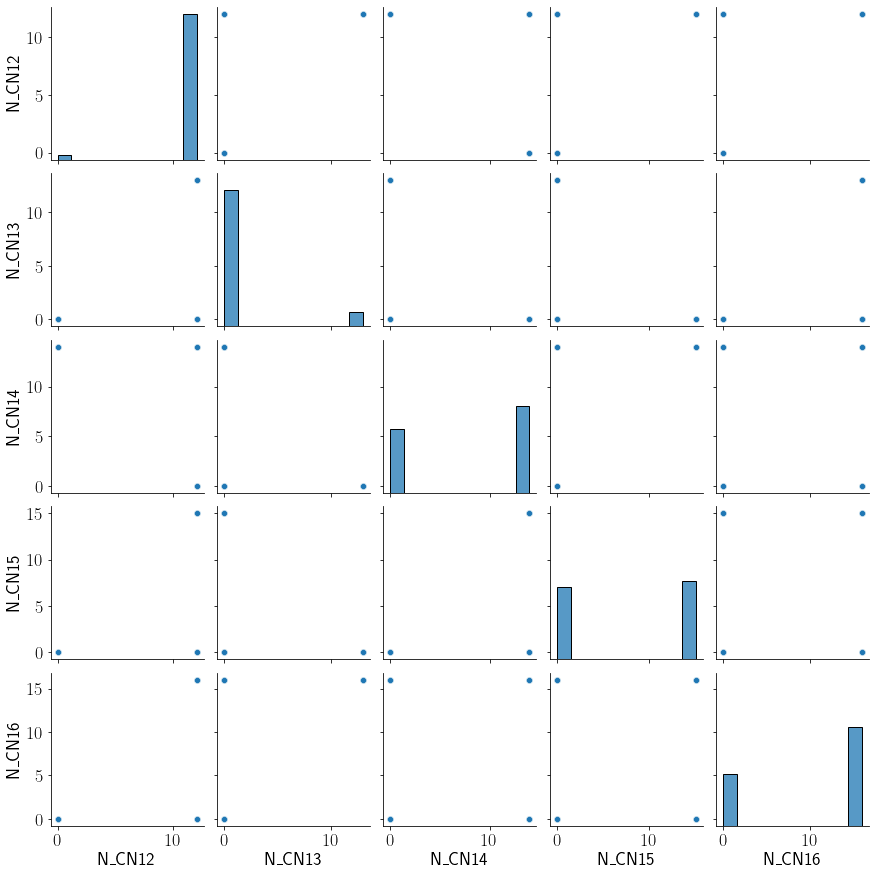

In [53]:
sns.pairplot(CN)

##  Correlations

In [54]:
plt.rc('font',size=22)

In [58]:
target_case = 'EF_nmhcp'

In [59]:
BS[target_case]

Fe_pv4Mo_sv20.C36-ABBBB.FM         0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM    0.133919
Fe_pv2Mo_sv11.mu-BBABB.FM          0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM       0.058290
Fe_pv2Mo_sv11.mu-BBBBA.NM          0.363607
                                     ...   
Fe_pv6.C15.FM                      0.144169
Mo_sv1.bcc.NM                      0.000000
Mo_sv8.A15.NM                      0.095306
Mo_sv1.fcc.NM                      0.421784
Mo_sv6.C15.NM                      0.367463
Name: EF_nmhcp, Length: 292, dtype: float64

In [61]:
FeatureGroups = {'density features': DensitiFeatures, 'atomic features': AtomicFeaturesMagpie, 'composition features': CompositionFeatures, 'Dataset Features': DatasetFeatures}
TargetCorrelations = {groupname: GroupFeatures.corrwith(BS[target_case]).abs().dropna().sort_values(ascending=False) for groupname, GroupFeatures in FeatureGroups.items()}

In [62]:
len(TargetCorrelations)

4

[None]

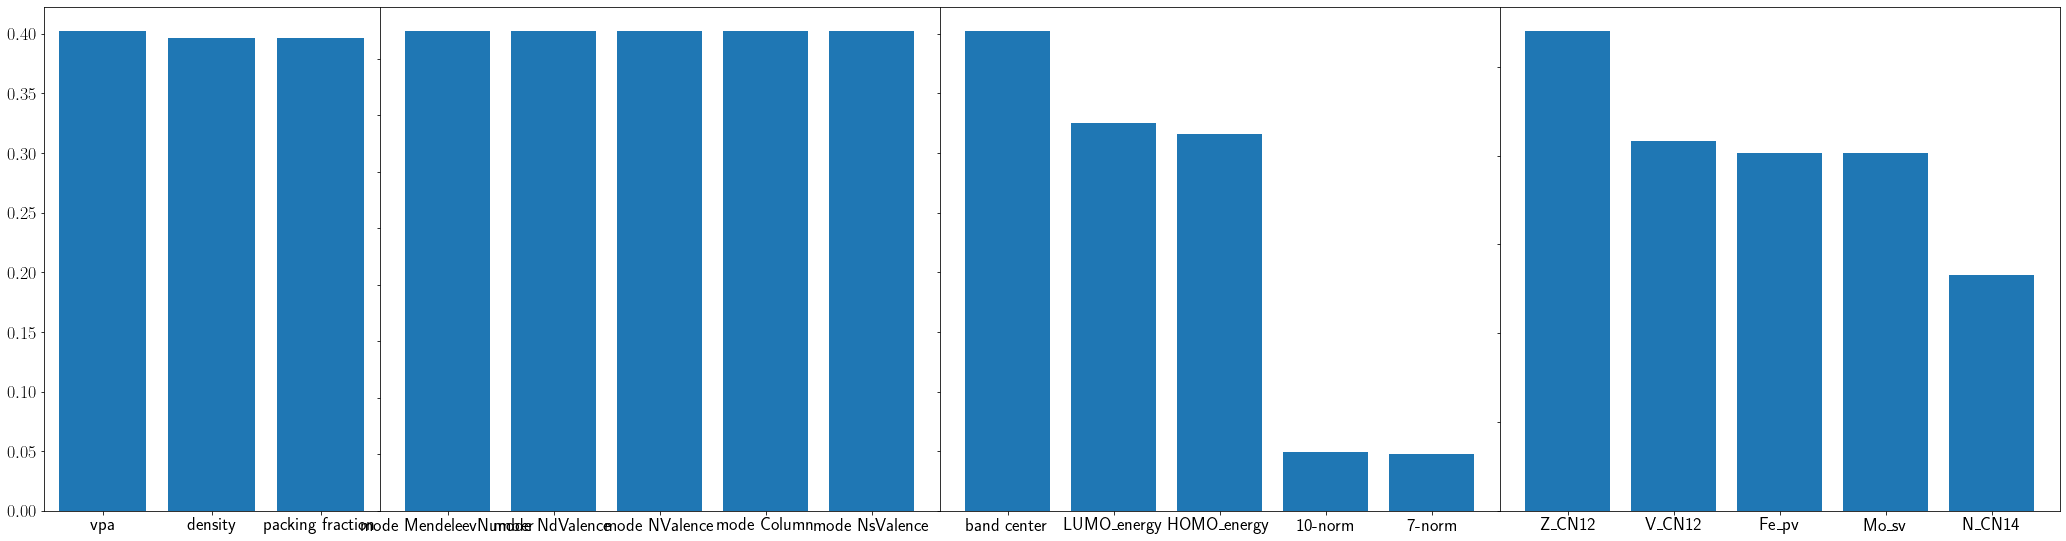

In [63]:
fig = plt.figure(figsize=(len(TargetCorrelations)*7, 10))
border=0
totalfeatures=18
for i, (group, TargetCorr) in enumerate(TargetCorrelations.items()):
    nfeatures = len(TargetCorr[:5])
    ax = fig.add_axes([border/totalfeatures,0.2,(nfeatures)/totalfeatures,0.7])
    border +=nfeatures
    ax.bar( TargetCorr[:5].index,TargetCorr[:5].values) #, ax = ax, orient='vertical')
axes = fig.get_axes()
[tax.set_yticklabels(tax.get_yticklabels(), visible=False) for tax in axes[1:]]
[tax.sharey(axes[0]) for tax in axes[:1]]
#axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90) 

# Plot correlations for most correlated

In [64]:
for name, item in DensitiFeatures.iteritems():
    print(name)

density
vpa
packing fraction


In [65]:
DensitiFeatures[DensitiFeatures.vpa < 6]

,density,vpa,packing fraction


<AxesSubplot:xlabel='vpa', ylabel='Count'>

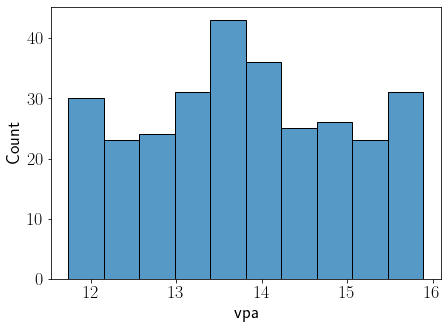

In [66]:
sns.histplot(DensitiFeatures.vpa)

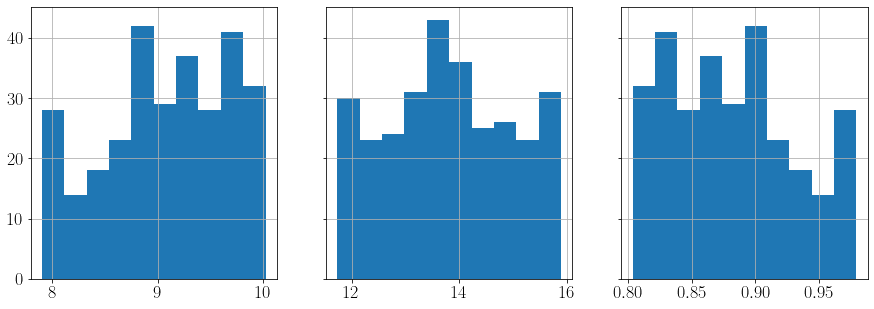

In [67]:
fig, axes = plt.subplots(1, 3, sharey = True, figsize=(15,5))
for (fname, feature), ax in zip(DensitiFeatures.iteritems(), axes):
    feature.hist(ax=ax)
#    sns.histplot(feature, ax =ax)

## By hand outlier detection:

In [68]:
selection = (FeatureGroups['density features']['packing fraction'] < 3) & (FeatureGroups['density features']['vpa']>8) &(FeatureGroups['density features']['density']<75)

In [73]:
def target_correlation_scatters(thisgroup, selection=None):
    featurenames = TargetCorrelations[thisgroup].index.to_list()
    if selection is None:
        selection = FeatureGroups[thisgroup].index
    nplots =  min([4, len(featurenames)])
    fig, axes = plt.subplots(1, nplots,  figsize=(7*4, 10), sharey=True)
    intersect = selection.intersection(BS[target_case].index)
    for ax, thisfeature in zip(axes, featurenames[:nplots]):
        ax.scatter(FeatureGroups[thisgroup][thisfeature][intersect], BS[target_case][intersect])
        ax.set_xlabel(thisfeature)
    axes[0].set_ylabel('$\Delta E_f$')

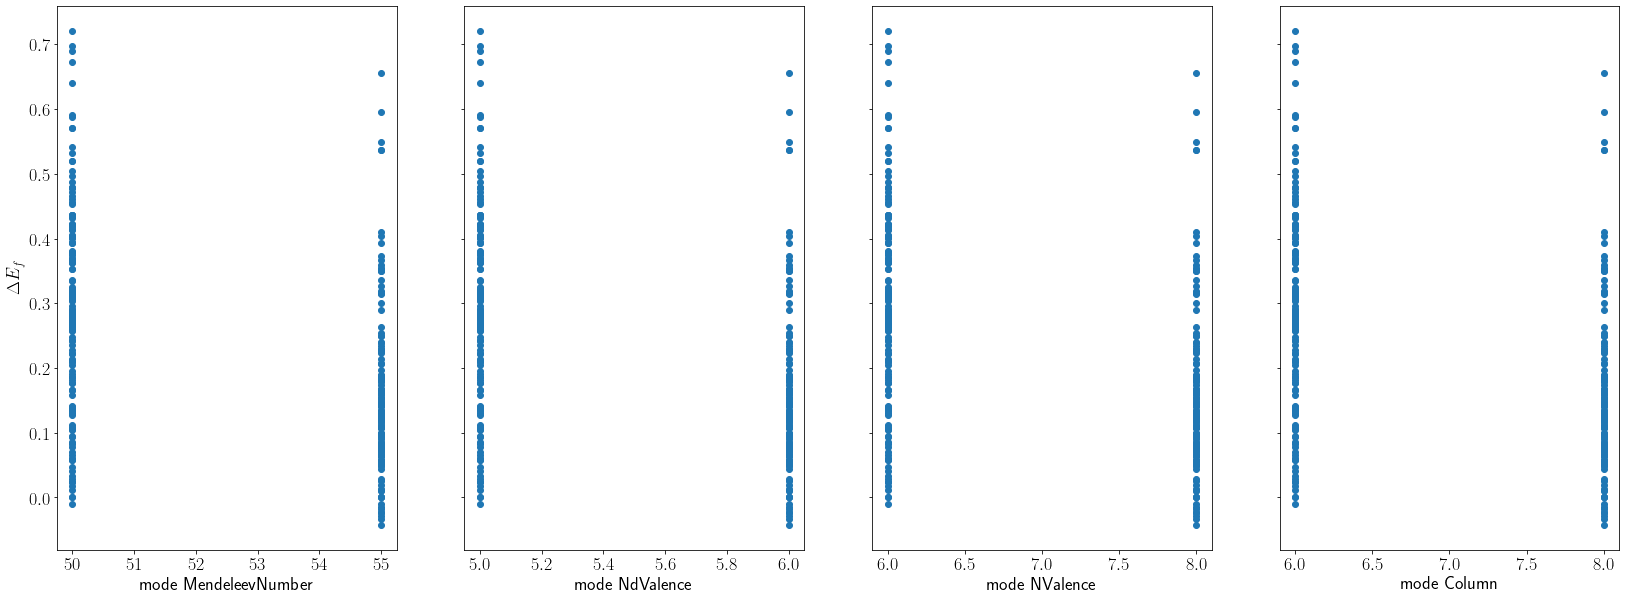

In [74]:
target_correlation_scatters('atomic features')

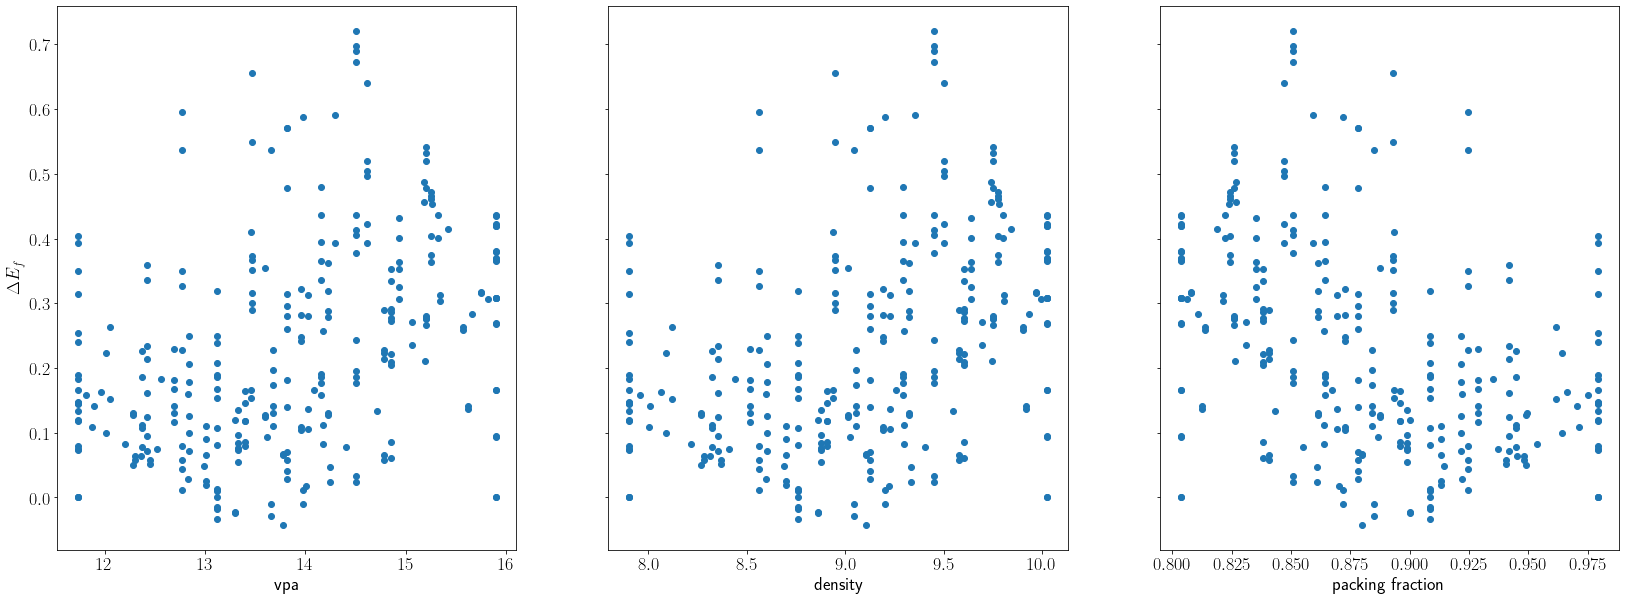

In [75]:
target_correlation_scatters('density features')#, selection=selection)

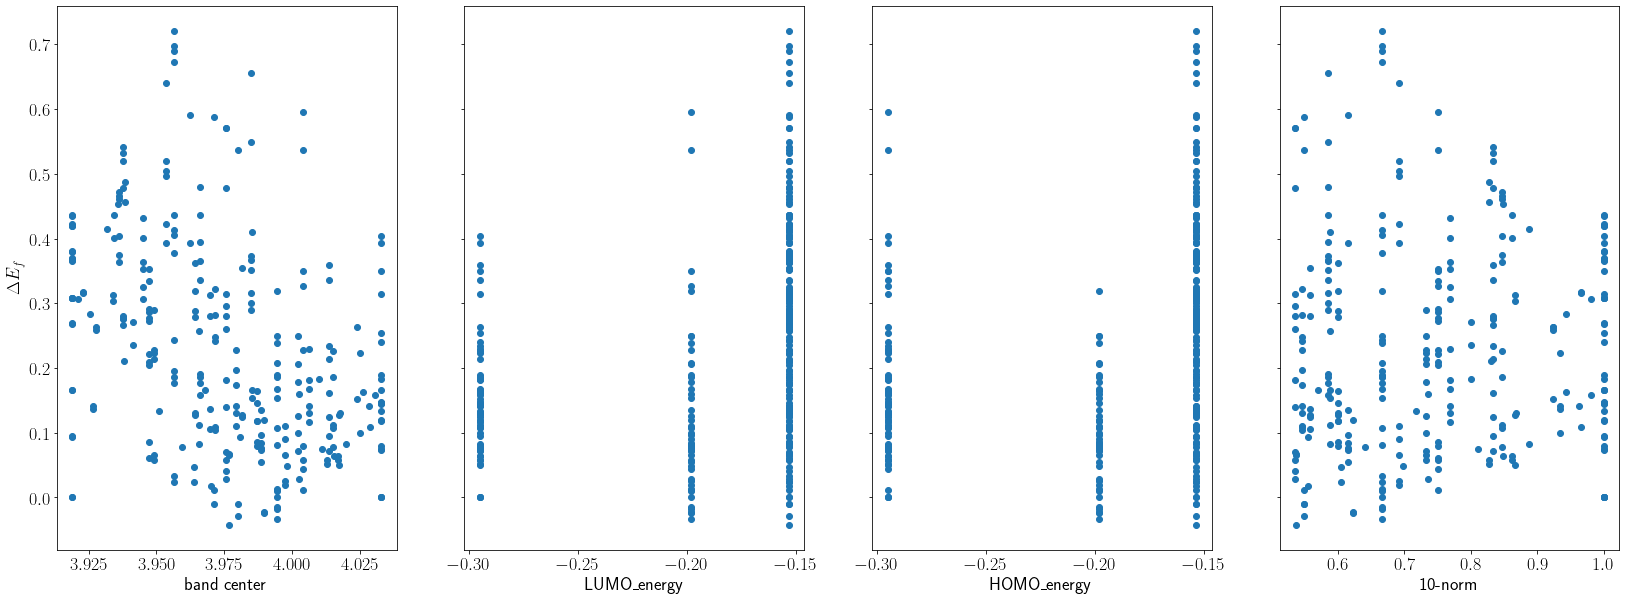

In [76]:
target_correlation_scatters('composition features')

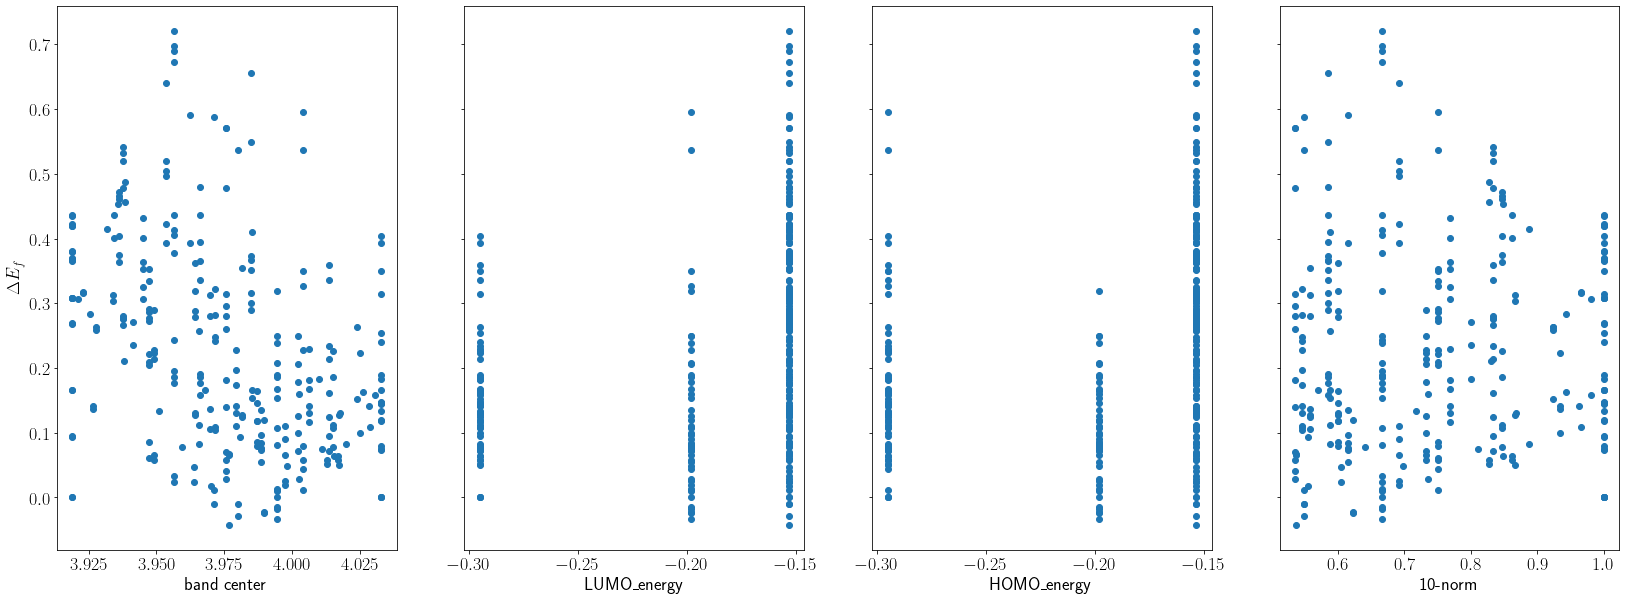

In [77]:
target_correlation_scatters('composition features')

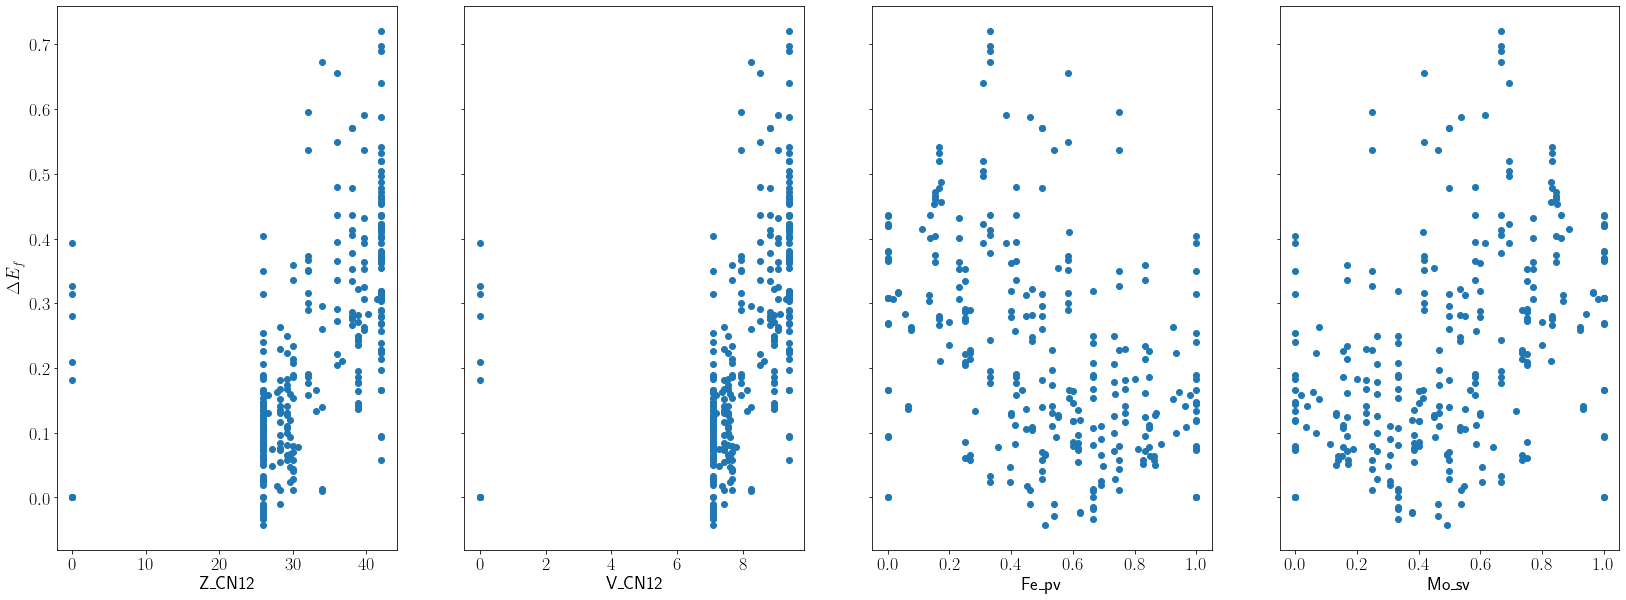

In [78]:
target_correlation_scatters('Dataset Features')

In [79]:
TargetCorrelations.keys()

dict_keys(['density features', 'atomic features', 'composition features', 'Dataset Features'])